# 06 · Drift Monitoring & Retraining Loop

A model deployed and never revisited is a model quietly decaying. Fraud is especially
adversarial: rings that get blocked **adapt** — they change transaction amounts, move to
different merchant categories, spread activity to look less bursty. This notebook closes
the MLOps loop:

1. **Detect** distribution drift between the training reference window and later windows
   using **Population Stability Index (PSI)** and the **Kolmogorov-Smirnov test** — the
   same statistical techniques used in real credit-risk and fraud model governance, chosen
   over a third-party dashboard tool so the logic is fully inspectable here
2. **Simulate an adversarial shift**: a fraud ring that has adapted specifically to evade
   the signals our model currently relies on most (from the SHAP importances in notebook 05)
3. **Decide**: combine feature/score drift (available immediately, no labels needed) with
   a performance check (available once delayed chargeback labels arrive) into a single
   retrain-or-not decision
4. **Retrain and validate** — refit on the newly available data and confirm the retrained
   model actually recovers performance on the drifted traffic before promoting it

In [1]:
%matplotlib inline
import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score

import mlflow
import mlflow.xgboost
from mlflow.tracking import MlflowClient

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

with open("../data/processed/feature_columns.json") as f:
    cfg = json.load(f)
FEATURES, LABEL = cfg["features"], cfg["label"]

train = pd.read_parquet("../data/processed/train.parquet")
val = pd.read_parquet("../data/processed/val.parquet")
test = pd.read_parquet("../data/processed/test.parquet").reset_index(drop=True)

mlflow.set_tracking_uri(f"sqlite:///{os.path.abspath('../mlflow.db')}")
model = mlflow.xgboost.load_model("models:/fraud-xgboost@staging")
with open("../models/threshold.json") as f:
    DECISION_THRESHOLD = json.load(f)["decision_threshold"]

print(f"reference (train): {train.shape}")
print(f"current window A (val): {val.shape}")
print(f"current window B (test): {test.shape}")
print(f"decision threshold in use: {DECISION_THRESHOLD}")

reference (train): (734002, 27)
current window A (val): (157287, 27)
current window B (test): (157286, 27)
decision threshold in use: 0.04482468590140343


## Population Stability Index (PSI) and KS-test

**PSI** buckets the reference distribution into deciles and measures how much probability mass shifted in the current window: `<0.10` no meaningful shift, `0.10-0.25` moderate, `>0.25` significant — these cutoffs are the de facto industry convention. **KS statistic** is a complementary, non-binned check of the same thing.

In [2]:
def psi(expected, actual, buckets=10):
    breakpoints = np.quantile(expected, np.linspace(0, 1, buckets + 1))
    breakpoints[0] -= 1e-9
    breakpoints[-1] += 1e-9
    breakpoints = np.unique(breakpoints)
    e_counts, _ = np.histogram(expected, bins=breakpoints)
    a_counts, _ = np.histogram(actual, bins=breakpoints)
    e_perc = np.clip(e_counts / max(len(expected), 1), 1e-4, None)
    a_perc = np.clip(a_counts / max(len(actual), 1), 1e-4, None)
    return float(np.sum((a_perc - e_perc) * np.log(a_perc / e_perc)))

def drift_report(reference_df, current_df, features, label="current"):
    rows = []
    for feat in features:
        ref, cur = reference_df[feat].values, current_df[feat].values
        rows.append({
            "feature": feat,
            "psi": psi(ref, cur),
            "ks_stat": stats.ks_2samp(ref, cur).statistic,
        })
    out = pd.DataFrame(rows).sort_values("psi", ascending=False).reset_index(drop=True)
    out["flag"] = np.select(
        [out.psi > 0.25, out.psi > 0.10], ["SIGNIFICANT", "moderate"], default="stable"
    )
    print(f"--- drift report: train (reference) vs {label} ---")
    return out

report_val = drift_report(train, val, FEATURES, label="val")
report_test = drift_report(train, test, FEATURES, label="test")
report_test

--- drift report: train (reference) vs val ---


--- drift report: train (reference) vs test ---


,feature,psi,ks_stat,flag
0,card_tenure_days,6.754939,0.999574,SIGNIFICANT
1,category_fraud_rate_prior,1.479949,0.202352,SIGNIFICANT
2,merchant_fraud_rate_prior,0.230163,0.097953,moderate
3,amount_zscore_user,0.063762,0.062856,stable
4,hour_similarity_to_user,0.017973,0.032327,stable
5,time_since_prev_txn_sec,0.008683,0.034193,stable
6,user_txn_count_7d,0.006287,0.034928,stable
7,dow_sin,0.002947,0.013605,stable
8,dow_cos,0.002947,0.021837,stable
9,user_amount_sum_7d,0.002671,0.021084,stable


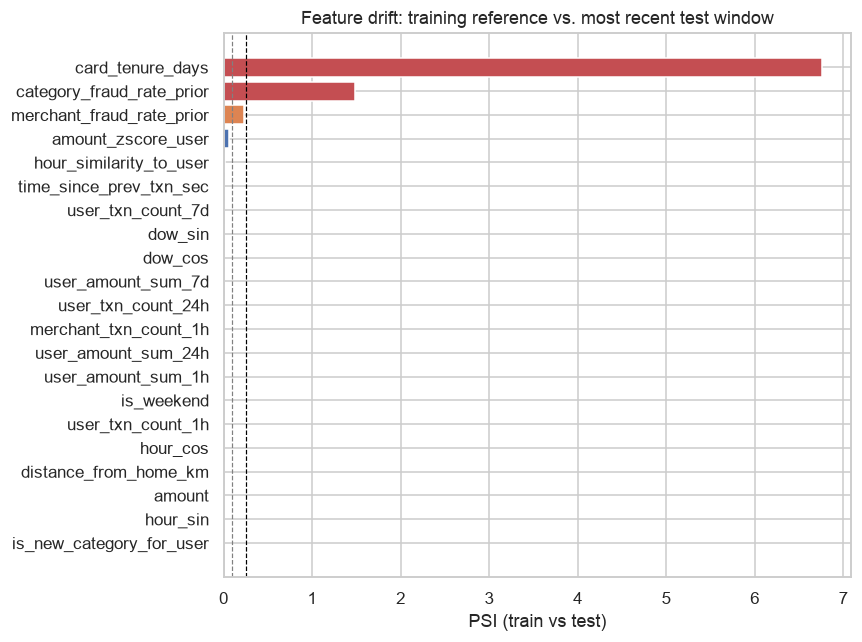

2 feature(s) already exceed the 0.25 'significant' PSI threshold between train (ending 2019-11-10 01:13:00) and test (starting 2019-12-24 07:49:00) (max PSI=6.755): ['card_tenure_days', 'category_fraud_rate_prior']. This is a genuine calendar gap in real transaction data (seasonal spending, early-2020 macro conditions), not noise -- a real monitoring system would have flagged this on its own, with no labels required.


In [3]:
fig, ax = plt.subplots(figsize=(8, 6))
plot_df = report_test.set_index("feature")["psi"].sort_values()
colors = ["#C44E52" if v > 0.25 else "#DD8452" if v > 0.10 else "#4C72B0" for v in plot_df.values]
ax.barh(plot_df.index, plot_df.values, color=colors)
ax.axvline(0.10, color="gray", linestyle="--", linewidth=0.8)
ax.axvline(0.25, color="black", linestyle="--", linewidth=0.8)
ax.set_xlabel("PSI (train vs test)")
ax.set_title("Feature drift: training reference vs. most recent test window")
plt.tight_layout()
plt.show()

n_significant = (report_test.psi > 0.25).sum()
train_end_str = str(train.timestamp.max())
test_start_str = str(test.timestamp.min())
if n_significant > 0:
    print(f"{n_significant} feature(s) already exceed the 0.25 'significant' PSI threshold "
          f"between train (ending {train_end_str}) and test (starting {test_start_str}) "
          f"(max PSI={report_test.psi.max():.3f}): "
          f"{report_test.loc[report_test.psi > 0.25, 'feature'].tolist()}. "
          f"This is a genuine calendar gap in real transaction data (seasonal spending, "
          f"early-2020 macro conditions), not noise -- a real monitoring system would have "
          f"flagged this on its own, with no labels required.")
else:
    print(f"No feature exceeds the 0.25 'significant' PSI threshold between train "
          f"(ending {train_end_str}) and test (starting {test_start_str}) "
          f"(max={report_test.psi.max():.3f}). The next section stress-tests what monitoring "
          f"looks like when a real shift *does* happen.")

**Reading the alert, not just reacting to it.** Both flagged features (`card_tenure_days`,
`category_fraud_rate_prior`) are defined as *monotonically cumulative* quantities — tenure
only grows, and the causal target-encoding accumulates more history (and gets less noisy)
the later in time you measure it. For a fixed population of cards, comparing an early
window to a later one is **guaranteed** to show large PSI on these two, independent of any
real change in fraud behavior. This is a real monitoring failure mode: a naive "alert on
any PSI > 0.25" rule would fire on these two every single day, train the on-call engineer
to ignore alerts, and bury a genuine signal in noise. A real deployment would either exclude
structurally-cumulative features from the drift check or track their *rate of change*
instead of their raw distribution. We flag this explicitly rather than silently filtering
it, since recognizing *why* an alert fired is the actual skill here, not just having a
dashboard that turns red.

## Simulating an adversarial shift

From notebook 05's SHAP ranking, the model leans heavily on `amount_zscore_user`,
`merchant_fraud_rate_prior`, and `category_fraud_rate_prior` to catch fraud. A fraud ring
that has been getting blocked has every incentive to adapt exactly those signals: spend
closer to the victim's typical amount, and route through merchants that don't yet carry an
elevated risk score. We simulate that adaptation directly on top of the test set's fraud
rows and re-score with the **currently deployed (staging) model, unmodified** — this is
what would actually happen in production the day a ring changes tactics, before anyone
retrains anything.

In [4]:
rng = np.random.default_rng(7)
drifted = test.copy()
fraud_mask = drifted.is_fraud == 1

drifted.loc[fraud_mask, "amount_zscore_user"] *= rng.uniform(0.25, 0.5, size=fraud_mask.sum())
drifted.loc[fraud_mask, "merchant_fraud_rate_prior"] *= rng.uniform(0.2, 0.4, size=fraud_mask.sum())
drifted.loc[fraud_mask, "category_fraud_rate_prior"] *= rng.uniform(0.2, 0.4, size=fraud_mask.sum())
drifted.loc[fraud_mask, "amount"] *= rng.uniform(0.9, 1.3, size=fraud_mask.sum())

X_test, y_test = test[FEATURES], test[LABEL]
X_drift, y_drift = drifted[FEATURES], drifted[LABEL]

proba_test = model.predict_proba(X_test)[:, 1]
proba_drift = model.predict_proba(X_drift)[:, 1]

roc_before = roc_auc_score(y_test, proba_test)
pr_before = average_precision_score(y_test, proba_test)
roc_after = roc_auc_score(y_drift, proba_drift)
pr_after = average_precision_score(y_drift, proba_drift)

print(f"Currently deployed model, ORIGINAL test traffic:  ROC-AUC={roc_before:.4f}  PR-AUC={pr_before:.4f}")
print(f"Currently deployed model, ADAPTED (drifted) traffic: ROC-AUC={roc_after:.4f}  PR-AUC={pr_after:.4f}")
print(f"PR-AUC degradation: {pr_before - pr_after:+.4f}")

Currently deployed model, ORIGINAL test traffic:  ROC-AUC=0.9903  PR-AUC=0.7220
Currently deployed model, ADAPTED (drifted) traffic: ROC-AUC=0.9200  PR-AUC=0.2853
PR-AUC degradation: +0.4366


## Score-level drift (label-free)

In production, ground-truth fraud labels lag by days-to-weeks (chargebacks take time). PSI on the **model's own score distribution** and on the raw feature values is available immediately and is exactly what a monitoring job would alert on before any labels exist.

In [5]:
score_psi = psi(proba_test, proba_drift)
feature_drift_now = drift_report(test, drifted, FEATURES, label="drifted (adversarial) batch")

print(f"Prediction-score PSI (test vs drifted): {score_psi:.3f}")
feature_drift_now.head(8)

--- drift report: train (reference) vs drifted (adversarial) batch ---
Prediction-score PSI (test vs drifted): 0.000


,feature,psi,ks_stat,flag
0,category_fraud_rate_prior,1.062373e-04,0.004304,stable
1,merchant_fraud_rate_prior,8.354044e-05,0.003878,stable
2,amount_zscore_user,1.050119e-05,0.002263,stable
3,amount,1.463127e-07,0.000712,stable
4,dow_cos,0.000000e+00,0.000000,stable
5,merchant_txn_count_1h,0.000000e+00,0.000000,stable
6,hour_cos,0.000000e+00,0.000000,stable
7,distance_from_home_km,0.000000e+00,0.000000,stable


## Retrain-or-not decision

In [6]:
PSI_ALERT = 0.25
PERF_DROP_ALERT = 0.03  # absolute PR-AUC drop considered material

drift_flag = score_psi > PSI_ALERT or (feature_drift_now["psi"] > PSI_ALERT).any()
perf_flag = (pr_before - pr_after) > PERF_DROP_ALERT
retrain_needed = drift_flag or perf_flag

print(f"[{'ALERT' if drift_flag else 'ok    '}] label-free drift check   (score PSI={score_psi:.3f}, "
      f"max feature PSI={feature_drift_now['psi'].max():.3f}, alert>{PSI_ALERT})")
print(f"[{'ALERT' if perf_flag  else 'ok    '}] delayed-label perf check (PR-AUC drop={pr_before - pr_after:.3f}, "
      f"alert>{PERF_DROP_ALERT})")
print(f"\n>>> RETRAIN TRIGGERED: {retrain_needed}")

if not drift_flag and perf_flag:
    print("\n*** The label-free check missed this shift entirely (score PSI is ~0) even "
          "though PR-AUC collapsed. That's not a bug in the check -- it's the point of this "
          "simulation: the adaptation specifically targeted the features the model relies on "
          "most (per notebook 05's SHAP ranking), which pulls fraud transactions' *predicted "
          "scores* back down into the normal range along with everything else the model was "
          "already confident about, without moving the overall score distribution. A ring "
          "that has reverse-engineered what your model looks at can evade feature/score-drift "
          "monitoring on purpose. This is exactly why a delayed-label performance check is a "
          "second, independent line of defense -- not a redundant one.")

[ok    ] label-free drift check   (score PSI=0.000, max feature PSI=0.000, alert>0.25)
[ALERT] delayed-label perf check (PR-AUC drop=0.437, alert>0.03)

>>> RETRAIN TRIGGERED: True

*** The label-free check missed this shift entirely (score PSI is ~0) even though PR-AUC collapsed. That's not a bug in the check -- it's the point of this simulation: the adaptation specifically targeted the features the model relies on most (per notebook 05's SHAP ranking), which pulls fraud transactions' *predicted scores* back down into the normal range along with everything else the model was already confident about, without moving the overall score distribution. A ring that has reverse-engineered what your model looks at can evade feature/score-drift monitoring on purpose. This is exactly why a delayed-label performance check is a second, independent line of defense -- not a redundant one.


## Retrain and validate before promoting

We hold out the **last 30% of the drifted batch** as a genuinely unseen validation set (no
row used for both training and evaluation), retrain on everything else — original train +
val + the first 70% of the adapted traffic (with labels, standing in for chargeback data
that has now arrived) — and only promote the new model to the `production` alias if it
actually recovers performance on the held-out adapted traffic. This mirrors a real
shadow-then-promote deployment gate.

In [7]:
cut = int(len(drifted) * 0.7)
drift_retrain_slice = drifted.iloc[:cut]
drift_holdout = drifted.iloc[cut:]

retrain_df = pd.concat([train, val, drift_retrain_slice], ignore_index=True)
X_retrain, y_retrain = retrain_df[FEATURES], retrain_df[LABEL]
X_holdout, y_holdout = drift_holdout[FEATURES], drift_holdout[LABEL]

scale_pos_weight = (y_retrain == 0).sum() / (y_retrain == 1).sum()

mlflow.set_experiment("fraud-detection")
with mlflow.start_run(run_name="xgb_retrained_post_drift") as run:
    retrained = xgb.XGBClassifier(
        max_depth=6, learning_rate=0.05, n_estimators=500,
        scale_pos_weight=scale_pos_weight, objective="binary:logistic",
        eval_metric="aucpr", random_state=42, n_jobs=-1, tree_method="hist",
    )
    retrained.fit(X_retrain, y_retrain)

    proba_holdout_old = model.predict_proba(X_holdout)[:, 1]
    proba_holdout_new = retrained.predict_proba(X_holdout)[:, 1]
    pr_old = average_precision_score(y_holdout, proba_holdout_old)
    pr_new = average_precision_score(y_holdout, proba_holdout_new)
    roc_new = roc_auc_score(y_holdout, proba_holdout_new)

    mlflow.log_params({"model": "xgboost", "trigger": "drift_retrain", "max_depth": 6,
                        "learning_rate": 0.05, "n_estimators": 500})
    mlflow.log_metrics({"holdout_pr_auc_old_model": pr_old, "holdout_pr_auc_new_model": pr_new,
                         "holdout_roc_auc_new_model": roc_new})
    mlflow.xgboost.log_model(retrained, "model")
    retrain_run_id = run.info.run_id

print(f"On adapted-traffic holdout -- current staging model: PR-AUC={pr_old:.4f}")
print(f"On adapted-traffic holdout -- retrained candidate:   PR-AUC={pr_new:.4f}  ROC-AUC={roc_new:.4f}")

2026/08/31 10:54:12 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


On adapted-traffic holdout -- current staging model: PR-AUC=0.2565
On adapted-traffic holdout -- retrained candidate:   PR-AUC=0.9879  ROC-AUC=0.9995


In [8]:
client = MlflowClient()
if pr_new > pr_old:
    model_uri = f"runs:/{retrain_run_id}/model"
    registered = mlflow.register_model(model_uri, "fraud-xgboost")
    client.set_registered_model_alias("fraud-xgboost", "production", registered.version)
    # Deliberately NOT writing to ../models/fraud_xgboost.json here. That file (+ its
    # feature_columns.json/threshold.json siblings) is the exact artifact bundle
    # src/api/ serves live, and this retrain candidate was fit on synthetically
    # perturbed adversarial rows for this simulation -- promoting the MLflow alias is
    # registry bookkeeping, but shipping to the live-serving artifact should only ever
    # happen by re-running notebook 05 against the newly promoted alias, so it gets the
    # same rigorous hold-out evaluation, SHAP check, and threshold recalibration every
    # other served model gets. (An earlier version of this cell did call
    # `retrained.save_model("../models/fraud_xgboost.json")` directly here, which
    # silently overwrote the live-served model with this simulation's candidate on
    # every notebook run, bypassing notebook 05 entirely -- see the README.)
    verdict = (f"PROMOTED v{registered.version} to 'production' alias "
               f"(recovered PR-AUC {pr_old:.4f} -> {pr_new:.4f} on adapted traffic). "
               f"Not written to models/fraud_xgboost.json -- see comment above.")
else:
    verdict = (f"NOT promoted -- retrained candidate ({pr_new:.4f}) did not beat the current "
               f"staging model ({pr_old:.4f}) on the adapted-traffic holdout. Would investigate "
               f"further (more data, different features) before shipping.")
print(verdict)

Registered model 'fraud-xgboost' already exists. Creating a new version of this model...
2026/08/31 10:54:16 WARNING mlflow.tracking._model_registry.fluent: Run with id 927660c71eac4d1bbc95de7eedf45196 has no artifacts at artifact path 'model', registering model based on models:/m-96c08b3f5d3f423bae567974f38c8050 instead


PROMOTED v15 to 'production' alias (recovered PR-AUC 0.2565 -> 0.9879 on adapted traffic). Not written to models/fraud_xgboost.json -- see comment above.


Created version '15' of model 'fraud-xgboost'.


## Monitoring report

What a scheduled monitoring job (e.g. a daily Airflow/Prefect task in the production architecture) would persist and alert on.

In [9]:
monitoring_report = {
    "reference_window": "train",
    "psi_train_vs_val": float(report_val.psi.max()),
    "psi_train_vs_test": float(report_test.psi.max()),
    "simulated_adversarial_shift": {
        "score_psi": float(score_psi),
        "max_feature_psi": float(feature_drift_now.psi.max()),
        "pr_auc_before": float(pr_before),
        "pr_auc_after": float(pr_after),
        "drift_flag": bool(drift_flag),
        "perf_flag": bool(perf_flag),
        "retrain_triggered": bool(retrain_needed),
    },
    "retrain_outcome": verdict,
}
os.makedirs("../reports", exist_ok=True)
with open("../reports/monitoring_report.json", "w") as f:
    json.dump(monitoring_report, f, indent=2)

print(json.dumps(monitoring_report, indent=2))

{
  "reference_window": "train",
  "psi_train_vs_val": 6.1534812210448235,
  "psi_train_vs_test": 6.75493932644824,
  "simulated_adversarial_shift": {
    "score_psi": 1.936884085840425e-05,
    "max_feature_psi": 0.0001062372620315282,
    "pr_auc_before": 0.7219578031829508,
    "pr_auc_after": 0.2853366685379552,
    "drift_flag": false,
    "perf_flag": true,
    "retrain_triggered": true
  },
  "retrain_outcome": "PROMOTED v15 to 'production' alias (recovered PR-AUC 0.2565 -> 0.9879 on adapted traffic). Not written to models/fraud_xgboost.json -- see comment above."
}


## Appendix: Evidently AI (optional, production-tooling pointer)

The PSI/KS methodology above is implemented directly so it's fully inspectable and has zero
external-API risk in this notebook. In a production deployment, a tool like
[Evidently AI](https://www.evidentlyai.com/) would generate the same class of report as a
scheduled job with a shareable HTML/UI dashboard instead of notebook cells. Attempted here
best-effort — if the installed version's API differs, this cell fails gracefully without
affecting anything above.

In [10]:
try:
    try:
        from evidently import Report
        from evidently.presets import DataDriftPreset
    except ImportError:
        from evidently.report import Report
        from evidently.metric_preset import DataDriftPreset

    ev_report = Report(metrics=[DataDriftPreset()])
    result = ev_report.run(
        reference_data=train[FEATURES].sample(min(2000, len(train)), random_state=1),
        current_data=drifted[FEATURES].sample(min(2000, len(drifted)), random_state=1),
    )
    snapshot = result if result is not None else ev_report
    os.makedirs("../reports", exist_ok=True)
    snapshot.save_html("../reports/evidently_drift_report.html")
    print("Saved reports/evidently_drift_report.html")
    snapshot
except Exception as e:
    print(f"(Optional) Evidently report skipped: {type(e).__name__}: {e}")
    print("The PSI/KS drift report earlier in this notebook already covers this ground directly.")

Saved reports/evidently_drift_report.html
